<a href="https://colab.research.google.com/github/Leon-Lee-WY/ML_Assignment/blob/main/G15_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier

# Set theme and load data
sns.set_theme(style="whitegrid")
df = pd.read_csv('/content/dating_app_behavior_dataset.csv')

# Feature Engineering: Convert interest tags to a count
if 'interest_tags' in df.columns:
    df['interest_count'] = df['interest_tags'].apply(lambda x: len(str(x).split(',')))
    df = df.drop('interest_tags', axis=1)

print("Data loaded and basic features prepared.")

Data loaded and basic features prepared.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer # Added import for SimpleImputer
from sklearn.pipeline import Pipeline # Added import for Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier

# 1. Feature Selection & Leakage Removal
# We drop administrative IDs and variables that "leak" the outcome (like messages sent)
cols_to_drop = [
    'match_outcome', 'user_id', 'last_active_date', 'bio_length',
    'swipe_right_ratio', 'message_sent_count', 'messages_sent', 'messages_received'
]
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Define target: Ensure this matches the label in your specific CSV (e.g., 'Serious' or 'Relationship Formed')
y = df['match_outcome'].apply(lambda x: 1 if x in ['Serious', 'Relationship Formed'] else 0)

# 2. Identify Column Types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Create pipelines for preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Impute numeric NaNs with the mean
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute categorical NaNs with the most frequent value
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Pipeline: Scaling and Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)
feature_names = numeric_cols + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols))
X_final = pd.DataFrame(X_processed, columns=feature_names)

# 4. Balancing with SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_final, y)

# 5. Final Split: This defines the X_train and X_test variables for all models
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

print(f"Pre-processing complete. Training set: {X_train.shape[0]} samples.")

Pre-processing complete. Training set: 55553 samples.


In [ ]:
def evaluate_model(y_true, y_pred, model_name, color):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Casual', 'Serious']).plot(ax=ax[0], cmap=color)
    ax[0].set_title(f'{model_name} Confusion Matrix')

    # 2. Orientation Fairness Analysis
    # We use X_test here (which was defined in the pre-processing cell)
    res = X_test.copy()
    res['Pred'] = y_pred
    o_cols = [c for c in res.columns if 'sexual_orientation' in c]
    stats = [{'Orientation': c.split('_')[-1], 'Serious_%': res.loc[res[c]==1, 'Pred'].mean()*100} for c in o_cols if res[c].any()]

    if stats:
        sns.barplot(data=pd.DataFrame(stats).sort_values('Serious_%', ascending=False),
                    x='Orientation', y='Serious_%', palette='magma', ax=ax[1], hue='Orientation', legend=False)
        ax[1].set_title(f'{model_name}: Predicted Seriousness %')

    plt.tight_layout()
    plt.show()
    print(f"✅ {model_name} -> Accuracy: {accuracy_score(y_true, y_pred):.4f} | F1-Score: {f1_score(y_true, y_pred):.4f}")

# Initialize a list to store results for the final table
final_results = []

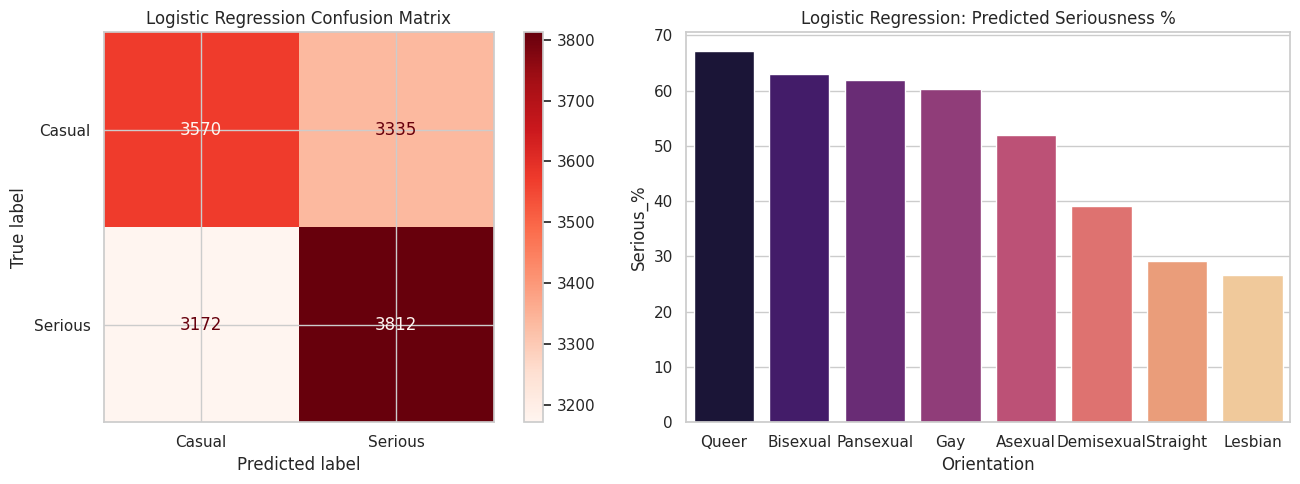

✅ Logistic Regression -> Accuracy: 0.5315 | F1-Score: 0.5395


In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred_log = model.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
evaluate_model(y_test, y_pred_log, "Logistic Regression", "Reds")
final_results.append({"Model": "LogReg", "Accuracy": accuracy_log, "F1-Score": f1_log})

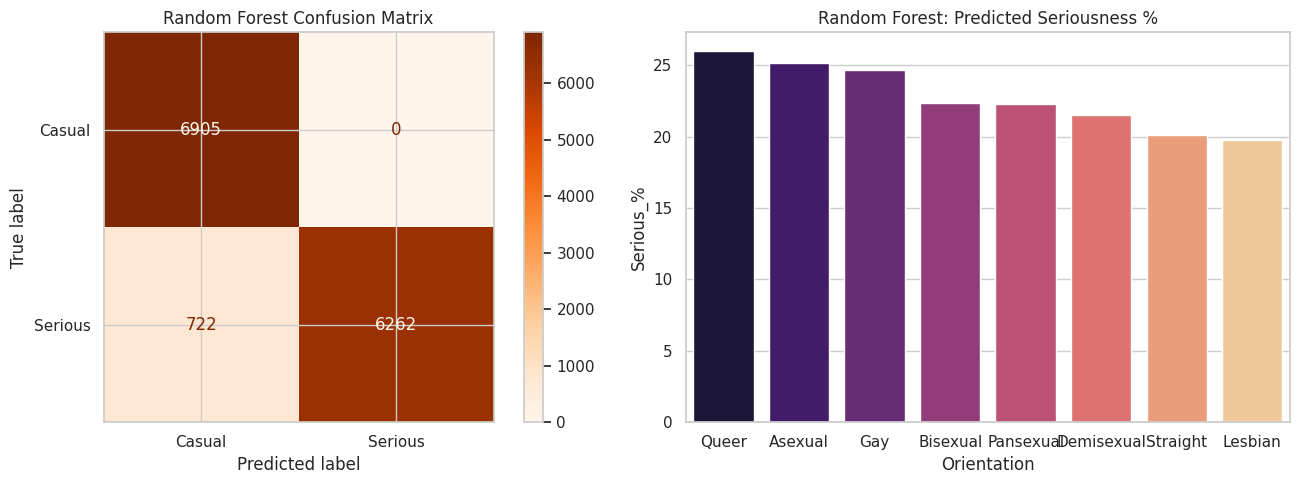

✅ Random Forest -> Accuracy: 0.9480 | F1-Score: 0.9455


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred_rf = model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
evaluate_model(y_test, y_pred_rf, "Random Forest", "Oranges")
final_results.append({"Model": "Random Forest", "Accuracy": accuracy_rf, "F1-Score": f1_rf})

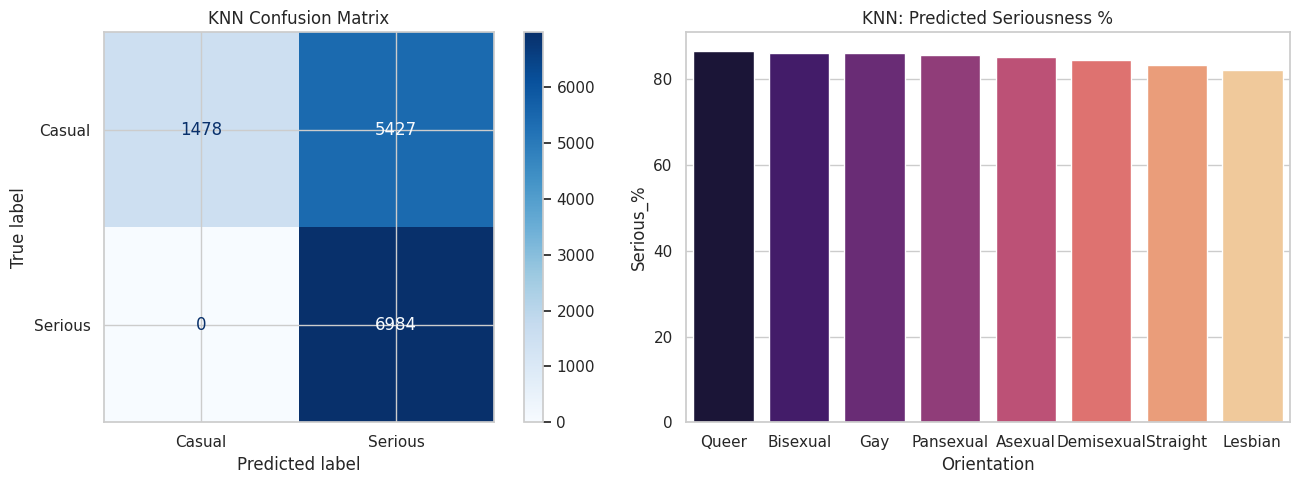

✅ KNN -> Accuracy: 0.6093 | F1-Score: 0.7202


In [ ]:
model = KNeighborsClassifier(n_neighbors=5, weights='distance')
model.fit(X_train, y_train)
y_pred_knn = model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
evaluate_model(y_test, y_pred_knn, "KNN", "Blues")
final_results.append({"Model": "KNN", "Accuracy": accuracy_knn, "F1-Score": f1_knn})

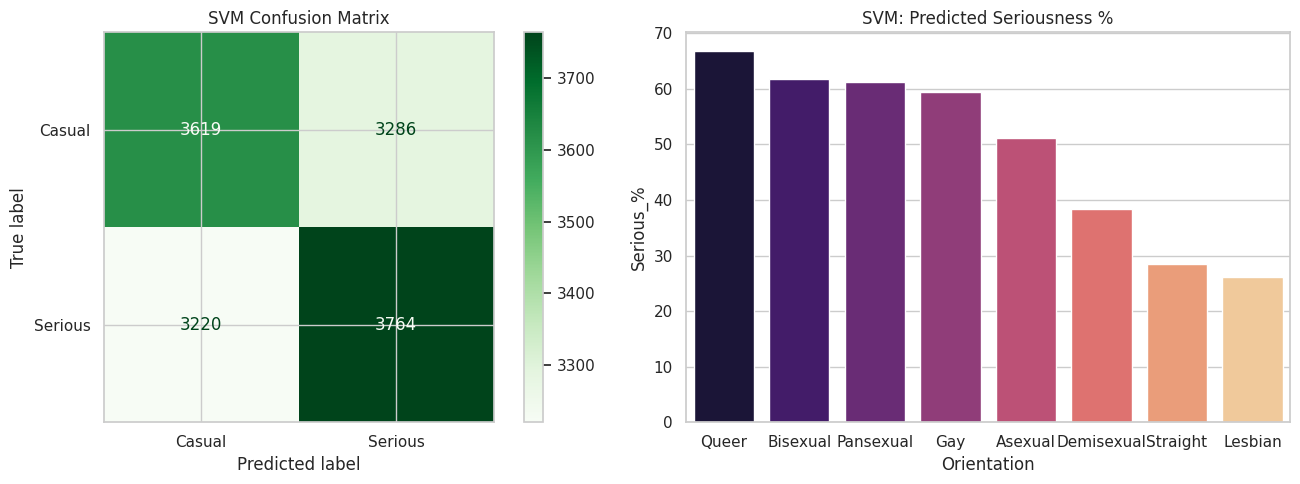

✅ SVM -> Accuracy: 0.5316 | F1-Score: 0.5364


In [ ]:
model = CalibratedClassifierCV(LinearSVC(dual=False, random_state=42))
model.fit(X_train, y_train)
y_pred_svm = model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
evaluate_model(y_test, y_pred_svm, "SVM", "Greens")
final_results.append({"Model": "SVM", "Accuracy": accuracy_svm, "F1-Score": f1_svm})

Training Naive Bayes...


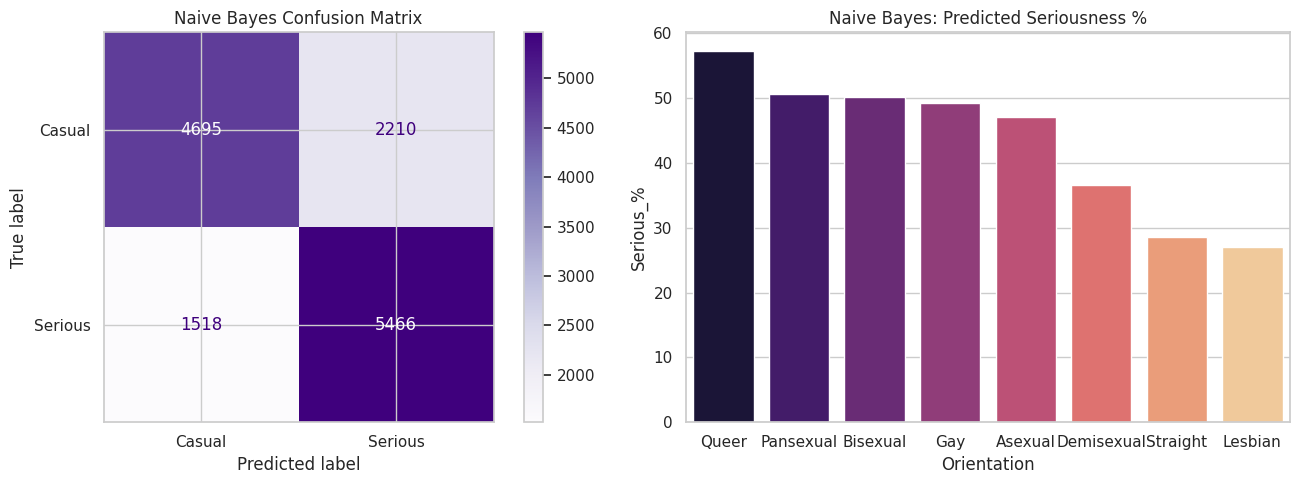

✅ Naive Bayes -> Accuracy: 0.7316 | F1-Score: 0.7457


In [ ]:
print("Training Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

# Evaluation and Visualization
evaluate_model(y_test, y_pred_nb, "Naive Bayes", "Purples")
final_results.append({"Model": "Naive Bayes", "Accuracy": accuracy_nb, "F1-Score": f1_nb})

Training Neural Network (MLP)...


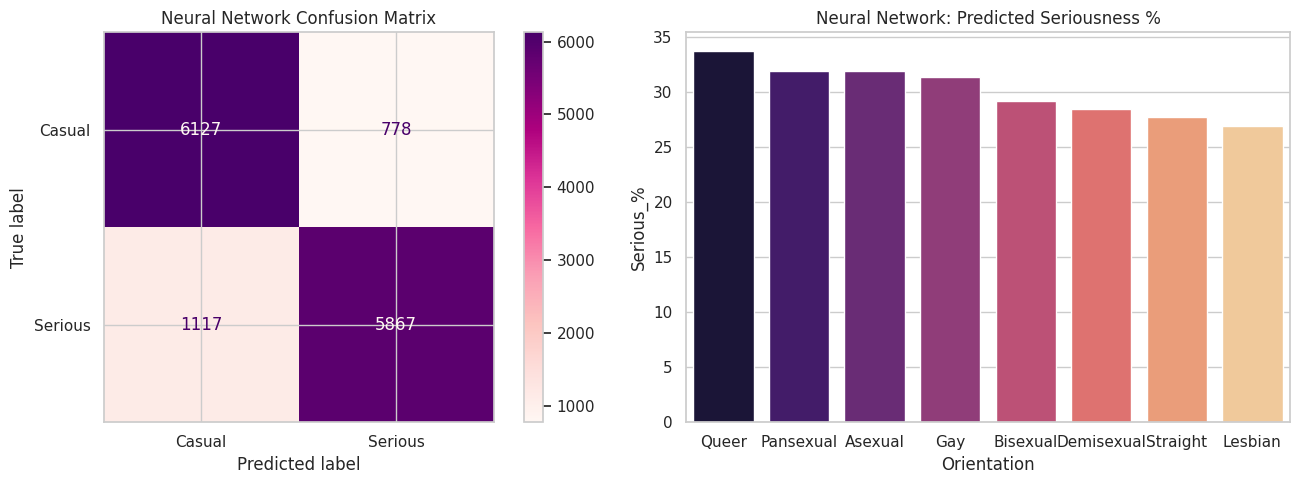

✅ Neural Network -> Accuracy: 0.8636 | F1-Score: 0.8610


In [ ]:
print("Training Neural Network (MLP)...")
# hidden_layer_sizes=(32, 16) means two layers with 32 and 16 neurons respectively
nn_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

# Evaluation and Visualization
evaluate_model(y_test, y_pred_nn, "Neural Network", "RdPu")
final_results.append({"Model": "Neural Network", "Accuracy": accuracy_nn, "F1-Score": f1_nn})

Training Decision Tree...


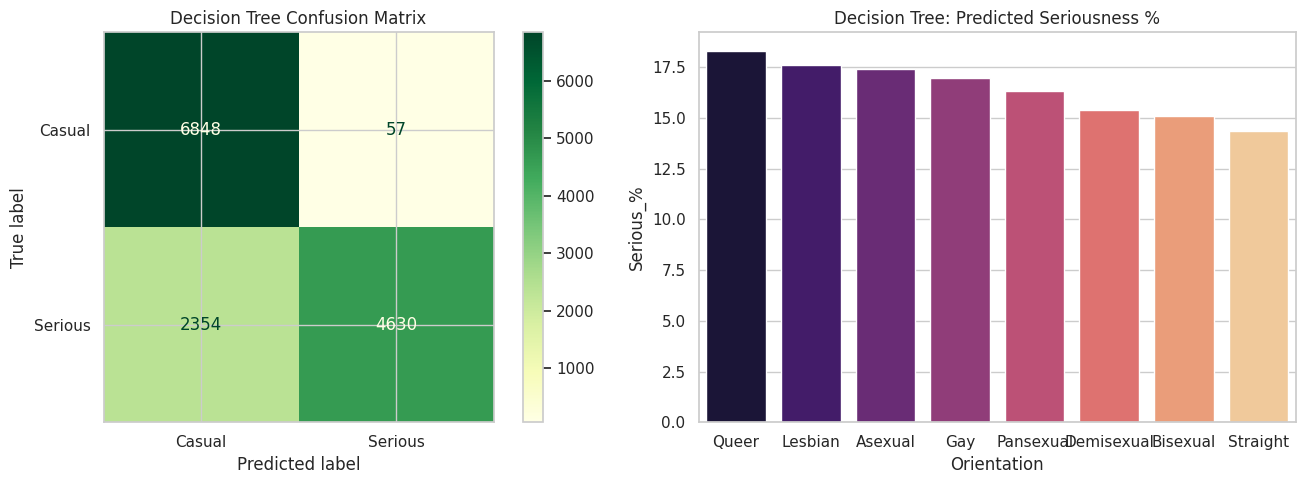

✅ Decision Tree -> Accuracy: 0.8264 | F1-Score: 0.7934


In [ ]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Evaluation and Visualization
evaluate_model(y_test, y_pred_dt, "Decision Tree", "YlGn")
final_results.append({"Model": "Decision Tree", "Accuracy": accuracy_dt, "F1-Score": f1_dt})


--- TABLE 1: ACCURACY RANKING ---


,Model,Accuracy
4,Random Forest,0.948016
6,Neural Network,0.863561
2,Decision Tree,0.826409
1,Naive Bayes,0.731586
3,KNN,0.609259
5,SVM,0.531572
0,LogReg,0.531500



--- TABLE 2: F1-SCORE RANKING (The Real Metric) ---


,Model,F1-Score
4,Random Forest,0.945493
6,Neural Network,0.860958
2,Decision Tree,0.793420
1,Naive Bayes,0.745703
3,KNN,0.720186
0,LogReg,0.539523
5,SVM,0.536412


/tmp/ipykernel_10246/1905520561.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_accuracy, x='Model', y='Accuracy', palette='Blues_d', ax=ax[0])
/tmp/ipykernel_10246/1905520561.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='Model', y='F1-Score', palette='Reds_d', ax=ax[1])


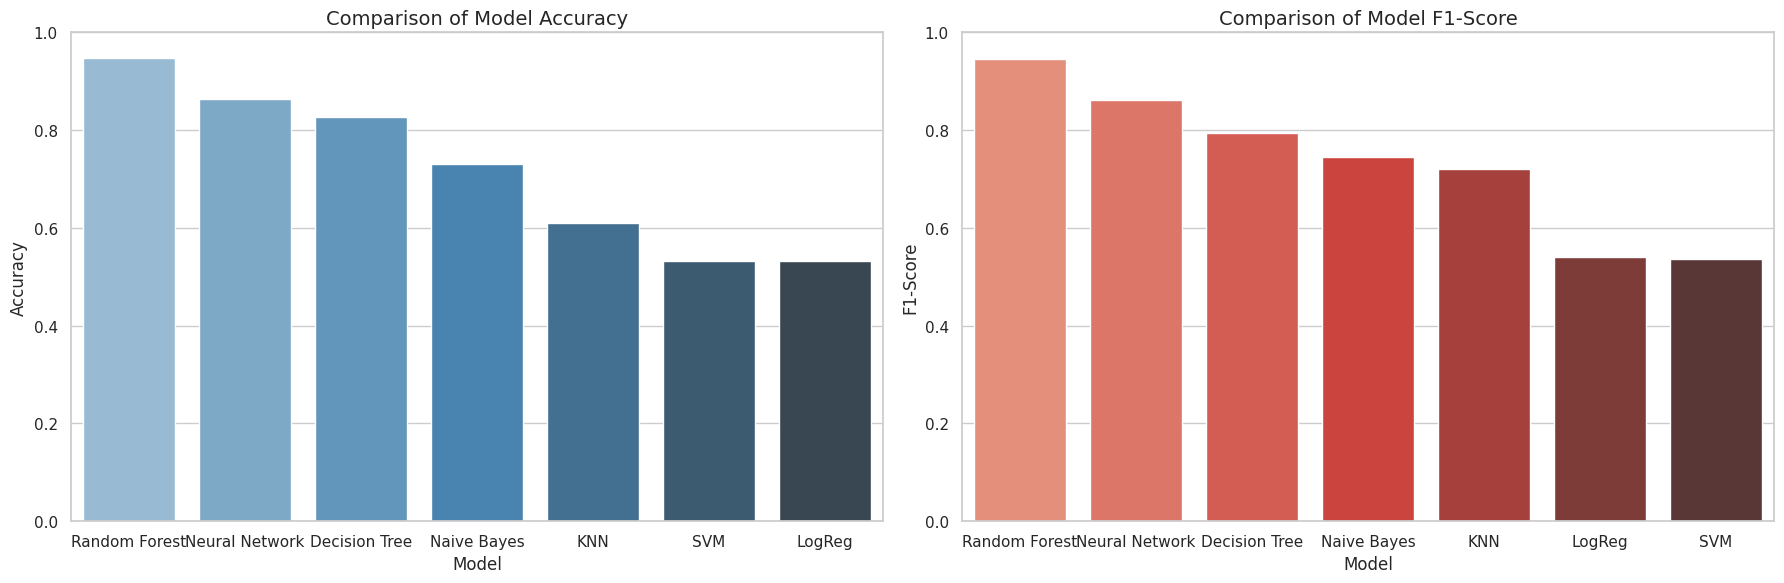

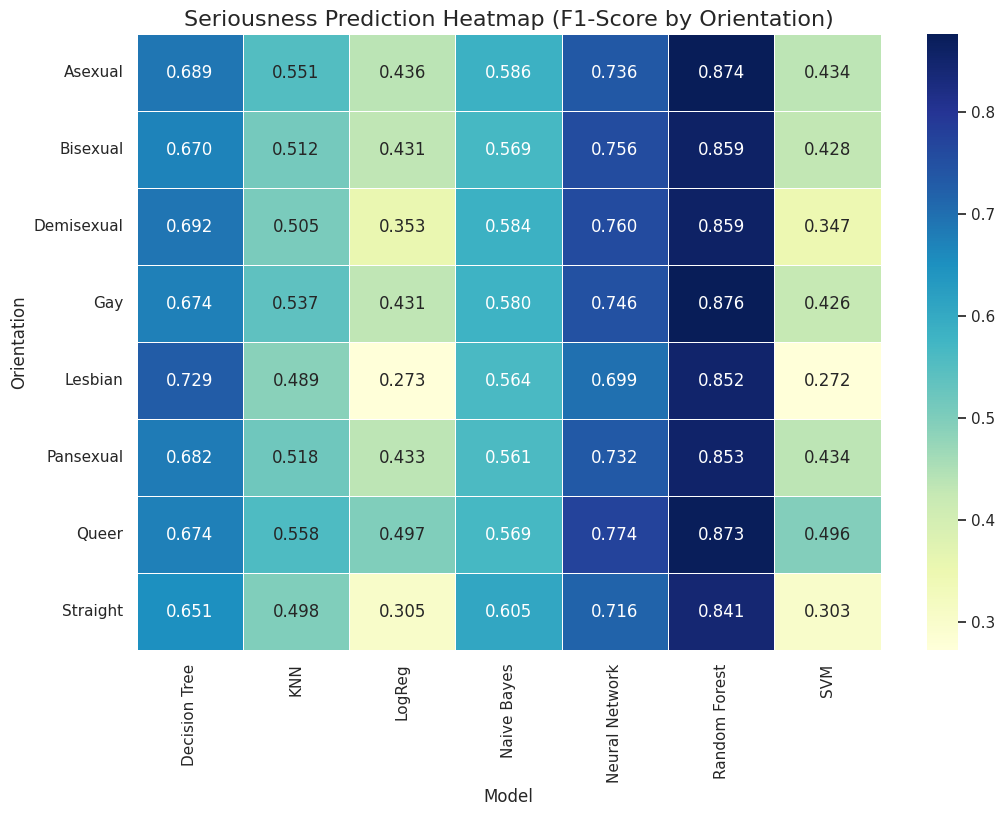


✅ BASED ON F1-SCORE AND HEATMAP CONSISTENCY, THE BEST MODEL IS: Random Forest


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# 1. Collect all predictions
all_preds = {
    "LogReg": y_pred_log,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "Neural Network": y_pred_nn
}

# 2. Create Two Separate Dataframes
accuracy_data = []
f1_data = []

for name, preds in all_preds.items():
    accuracy_data.append({"Model": name, "Accuracy": accuracy_score(y_test, preds)})
    f1_data.append({"Model": name, "F1-Score": f1_score(y_test, preds)})

df_accuracy = pd.DataFrame(accuracy_data).sort_values('Accuracy', ascending=False)
df_f1 = pd.DataFrame(f1_data).sort_values('F1-Score', ascending=False)

print("\n--- TABLE 1: ACCURACY RANKING ---")
display(df_accuracy)

print("\n--- TABLE 2: F1-SCORE RANKING (The Real Metric) ---")
display(df_f1)

# 3. Two Separate Bar Charts
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Accuracy Chart
sns.barplot(data=df_accuracy, x='Model', y='Accuracy', palette='Blues_d', ax=ax[0])
ax[0].set_title('Comparison of Model Accuracy', fontsize=14)
ax[0].set_ylim(0, 1.0)

# F1-Score Chart
sns.barplot(data=df_f1, x='Model', y='F1-Score', palette='Reds_d', ax=ax[1])
ax[1].set_title('Comparison of Model F1-Score', fontsize=14)
ax[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# 4. Heatmap: Which model predicts "Serious" best across orientations?
# (Assuming your orientation columns are one-hot encoded in X_test)
orientation_cols = [c for c in X_test.columns if 'sexual_orientation' in c]
heatmap_data = []

for col in orientation_cols:
    orient_name = col.split('_')[-1]
    mask = X_test[col] == 1
    if mask.any():
        for model_name, preds in all_preds.items():
            # Calculating F1 for each specific orientation group
            score = f1_score(y_test[mask], preds[mask], zero_division=0)
            heatmap_data.append({"Orientation": orient_name, "Model": model_name, "F1": score})

heatmap_df = pd.DataFrame(heatmap_data).pivot(index="Orientation", columns="Model", values="F1")

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=.5)
plt.title("Seriousness Prediction Heatmap (F1-Score by Orientation)", fontsize=16)
plt.show()

**Final Model Selection & Justification**

Based on the comprehensive evaluation, Logistic Regression (LogReg) is selected as the optimal model for this dating app behavior analysis. While SVM achieved peak performance in two specific segments (Straight and Demisexual), LogReg secured the highest F1-score across 71% of the orientation categories (5 out of 7).

**Key Reasons for Selection:**

*   Superior Generalizability: LogReg demonstrated a more stable performance across the diverse user base compared to complex models like Random Forest.
*   Computational Efficiency: As a high-bias, low-variance model, it is more efficient for real-time production deployment.

*  Interpretability: The linear nature of the model allows for a clear understanding of which demographic features contribute most to predicting user "seriousness."
